# Task 1: Evaluate SDG on TSV Model

Input: headword w, sense definition proposal d for a sense s and a set of retrieved usages U_w for w

Output: New definition d’ for s


In [ ]:
import os
import pandas as pd

# preset paths
BASE_DIR = "/home/users1/saxjs/BASax/johannes/autodict/pipeline"
RESULT_DIR = "/home/users1/saxjs/BASax/johannes/eval/results"

print(f"BASE_DIR: {BASE_DIR}")
print(f"RESULT_DIR: {RESULT_DIR}")

In [37]:
def run_outlier2cluster(name, dictionary_s3, usage_path, threshold_s3=0.4, max_usage_length_s3=512):
    """
    Run outlier2cluster analysis for sense definition generation evaluation.
    
    Parameters:
    -----------
    name : str
        Name of the experiment/run
    dictionary_s3 : str
        Path to dictionary file
    usage_path : str
        Path to usage data file
    threshold_s3 : float, default=0.4
        Threshold for outlier2cluster
    max_usage_length_s3 : int, default=512
        Maximum usage length
        
    Returns:
    --------
    pandas.DataFrame
        o2c output results
    """
    
    # Model weights path
    model_weights_s3 = os.path.join(BASE_DIR, "outlier2cluster/o2c/data/models/NSD/NSD_own_dev.pkl")
    
    
    result_path = f"{RESULT_DIR}/{name}"
    if os.path.exists(result_path):
        o2c_req = True
        print(f"Directory {result_path} already exists")
    else:
        o2c_req = True
        # Create directory if not exists
        os.makedirs(result_path, exist_ok=True)
        print(f"Directory {result_path} created, proceeding with outlier2cluster.")

    # Run outlier2cluster script from the pipeline
    if o2c_req:
        cmd = (
            f'python "{BASE_DIR}/outlier2cluster/o2c/code/main.py" '
            f'--dictionary "{dictionary_s3}" '
            f'--usages "{usage_path}" '
            f'--thresh "{threshold_s3}" '
            f'--result_dir "{result_path}" '
            f'--nsd_weights "{model_weights_s3}" '
            f'--context_limit "{max_usage_length_s3}" '
            f'--delete_embeddings'
        )
        print("Running:", cmd)
        os.system(cmd)

    # Load S3 results
    s3out = pd.read_csv(f"{result_path}/result_raw.tsv", sep='\t')
    #print("S3 Output Preview:")
    #print(s3out.head(2))
    
    return s3out

In [38]:
###RUN o2c bundles

import time

def create_tsv_format_foro2c_bundle(dictionary, usages):
    """
    Create TSV format data and run o2c running 1 sense of multiple lemmas at once.
    
    Parameters:
    -----------
    dictionary : string
        path to dictionary file
    usages : string
        path to usages file

    Returns:
    --------
    pandas.DataFrame
        DataFrame containing the dataset
    """
    
    step_sense_path= f"{RESULT_DIR}/sense_step.tsv"
    step_usage_path = f"{RESULT_DIR}/usage_tsv_step.tsv"


    # Load dictionary and usages
    dict_df = pd.read_csv(dictionary, sep='\t')
    usages_df = pd.read_csv(usages, sep='\t')

    # Remove dictionary entries with no usages
    #print("Removing dictionary entries with no usages... current size:", len(dict_df))
    #dict_df = dict_df[dict_df['sense_id'].isin(usages_df['sense_id_gold'])]
    #print("New dictionary size:", len(dict_df))

    #same columns as usages_df
    full_dataset = pd.DataFrame(columns=usages_df.columns)

    # Iterate over dictionary entries grouped by lemma
    grouped_dict = dict_df.groupby('lemma')
    stop=0
    usages_for_step = pd.DataFrame(columns=usages_df.columns)
    senses_for_step = pd.DataFrame(columns=dict_df.columns)

    #get group with most rows
    max_group_size = grouped_dict.size().max()

    #for lemma, group in grouped_dict:
    #range from 0 to maximum size of grouped_dict
    print("Processing grouped dictionary entries...")
    print(f"maximum size of each group: {max_group_size}")
    for step in range(0,max_group_size):

        # Reset Step DataFrames
        usages_for_step = pd.DataFrame(columns=usages_df.columns)
        senses_for_step = pd.DataFrame(columns=dict_df.columns)
        usages_for_step['tsv_step_sense'] = 0  # Initialize all to 0

        # get row of each group at position step
        for lemma, group in grouped_dict:
            # Check if the current group has enough rows for this step
            if step < len(group):
                sense_id = group.iloc[step]['sense_id']
                usages = usages_df[usages_df['lemma'] == lemma].copy()
                # Keep only the sense at position step
                step_sense = group[group['sense_id'] == sense_id].copy()
                # Create tsv_label column and set it to 0
                usages = usages.copy()
                usages['tsv_label'] = 0  # Initialize all to 0
                usages.loc[usages['sense_id_gold'] == sense_id, 'tsv_label'] = 1

                # add current step sense to output
                usages['tsv_step_sense'] = sense_id
                


                senses_for_step = pd.concat([senses_for_step, step_sense], ignore_index=True)
                usages_for_step = pd.concat([usages_for_step, usages], ignore_index=True)

        usages_for_step.to_csv(f"{RESULT_DIR}/usage_tsv_step.tsv", sep='\t', index=False)
        senses_for_step.to_csv(f"{RESULT_DIR}/sense_step.tsv", sep='\t', index=False)
        

        # start timer
        start_time = time.time()

            
        #run 02c now
        o2c_output_step = run_outlier2cluster(
                    name="o2c_step",
                    dictionary_s3=step_sense_path,
                    usage_path=step_usage_path,
                    threshold_s3=0.4,
                    max_usage_length_s3=512)
            
        full_dataset = pd.concat([full_dataset, o2c_output_step], ignore_index=True)
        # end timer
        end_time = time.time()
        elapsed_time = end_time - start_time
        print(f"Processed first '{len(o2c_output_step)}' in {elapsed_time:.2f} seconds.")
        full_dataset.to_csv(f"{RESULT_DIR}/running_tsv_run.tsv", sep='\t')
        #break  # Stop after processing the first lemma

    
    return full_dataset

In [39]:
import time

def create_tsv_format_foro2c(dictionary, usages):
    """
    ATTENTION! ATTENTION! SLOW IMPLEMENTATION! ATTENTION! ATTENTION!
    Create TSV format data and run o2c.
    
    Parameters:
    -----------
    dictionary : string
        path to dictionary file
    usages : string
        path to usages file

    Returns:
    --------
    pandas.DataFrame
        DataFrame containing the dataset
    """
    
    step_sense_path= f"{RESULT_DIR}/sense_step.tsv"
    step_usage_path = f"{RESULT_DIR}/usage_tsv_step.tsv"


    # Load dictionary and usages
    dict_df = pd.read_csv(dictionary, sep='\t')
    usages_df = pd.read_csv(usages, sep='\t')

    # Remove dictionary entries with no usages
    print("Removing dictionary entries with no usages... current size:", len(dict_df))
    dict_df = dict_df[dict_df['sense_id'].isin(usages_df['sense_id_gold'])]
    print("New dictionary size:", len(dict_df))

    #same columns as usages_df
    full_dataset = pd.DataFrame(columns=usages_df.columns)

    # Iterate over dictionary entries grouped by lemma
    grouped_dict = dict_df.groupby('lemma')
    stop=0

    for lemma, group in grouped_dict:
        usages_for_sense = usages_df[usages_df['lemma'] == lemma].copy()  # Create explicit copy
        for i, row in group.iterrows():
            # Get usages for the current sense_id
            sense_id = row['sense_id']
            # Create tsv_label 1 for correlated usages, 0 for outliers
            usages_for_sense.loc[:, 'tsv_label'] = 0  # Initialize all to 0
            usages_for_sense.loc[usages_for_sense['sense_id_gold'] == sense_id, 'tsv_label'] = 1

            usages_for_sense.to_csv(f"{RESULT_DIR}/usage_tsv_step.tsv", sep='\t', index=False)
            #create dataset from current row
            sense_inv_step = group.copy()
            #remove all but current row
            sense_inv_step = sense_inv_step[sense_inv_step['sense_id'] == sense_id]
            # Save the sense_inv_step to a file
            sense_inv_step.to_csv(f"{RESULT_DIR}/sense_step.tsv", sep='\t', index=False)

            # start timer
            start_time = time.time()

            
            #run 02c now
            o2c_output_step = run_outlier2cluster(
                    name="o2c_step",
                    dictionary_s3=step_sense_path,
                    usage_path=step_usage_path,
                    threshold_s3=0.4,
                    max_usage_length_s3=512)
            
            full_dataset = pd.concat([full_dataset, o2c_output_step], ignore_index=True)
            # end timer
            end_time = time.time()
            elapsed_time = end_time - start_time
            print(f"Processed lemma '{lemma}' in {elapsed_time:.2f} seconds.")
            break  # Stop after processing the first lemma

        stop += 1
        if stop > 500:
            print("Stopping after processing 20 lemmas.")
            break  # Stop after processing the first 20 lemmas
        if stop % 10 == 0:
            print(f"Processed {stop} lemmas so far.")
            full_dataset.to_csv(f"{RESULT_DIR}/running_tsv_run_fews_def.tsv", sep='\t')

    
    return full_dataset

# MAIN

In [40]:
# Example usage of the outlier2cluster analysis function
name = "test_pilot"  # fews_short_generated_definition #"s1_t_0_19_s3_gen_def_gen_def_usages"

# Define paths
#dictionary_path = "/home/users1/saxjs/BASax/FEWS/own_dev_fews/GOLD_FEWS_DEF/sense_inv_lem+notlem.tsv"#"/home/users1/saxjs/BASax/FEWS/own_dev_fews/GOLD_FEWS_DEF/sense_inv_lem+notlem.tsv"
#dictionary_path = "/home/users1/saxjs/BASax/johannes/eval/pilot_f/pilot_f_dict.tsv"#"/home/users1/saxjs/BASax/FEWS/own_dev_fews/GOLD_FEWS_DEF/sense_inv_lem+notlem.tsv"
dictionary_path = "/home/users1/saxjs/BASax/ba_pipeline/OUTFews3/pilot_generated_definitions.tsv"
#dictionary_path = "/home/users1/saxjs/BASax/johannes/eval/pilot_f/pilot_f_dict.tsv"
#dictionary_path = "/home/users1/saxjs/BASax/ba_pipeline/OUTFews3/gen_def_gen_def_lemur+usages.tsv"

#usage_path = "/home/users1/saxjs/BASax/FEWS/own_dev_fews/GOLD_FEWS_DEF/gold_data_fews.tsv"
usage_path = "/home/users1/saxjs/BASax/johannes/eval/pilot_f/pilot_f_usages.tsv"


full_tsv_run=create_tsv_format_foro2c_bundle(dictionary_path, usage_path)


Processing grouped dictionary entries...
maximum size of each group: 14
Directory /home/users1/saxjs/BASax/johannes/eval/results/o2c_step already exists
Running: python "/home/users1/saxjs/BASax/johannes/autodict/pipeline/outlier2cluster/o2c/code/main.py" --dictionary "/home/users1/saxjs/BASax/johannes/eval/results/sense_step.tsv" --usages "/home/users1/saxjs/BASax/johannes/eval/results/usage_tsv_step.tsv" --thresh "0.4" --result_dir "/home/users1/saxjs/BASax/johannes/eval/results/o2c_step" --nsd_weights "/home/users1/saxjs/BASax/johannes/autodict/pipeline/outlier2cluster/o2c/data/models/NSD/NSD_own_dev.pkl" --context_limit "512" --delete_embeddings


23:26:44 - INFO - Remove embeddings
23:26:44 - INFO - Transform files to axolotl format
23:26:44 - INFO - Prepare required models
23:26:44 - INFO - Gloss Reader model.safetensors already exists at /mount/arbeitsdaten20/projekte/cik/users/johannes/autodict/pipeline/outlier2cluster/o2c/data/models/GR_FiEnRu/model.safetensors, skip download.
23:26:44 - INFO - Gloss Reader model.pt already exists at /mount/arbeitsdaten20/projekte/cik/users/johannes/autodict/pipeline/outlier2cluster/o2c/data/models/GR/model.pt, skip download.
23:26:44 - INFO - Start vectorization of dictionary entries and usages


Namespace(model='/mount/arbeitsdaten20/projekte/cik/users/johannes/autodict/pipeline/outlier2cluster/o2c/data/models/GR_FiEnRu/model.safetensors', datasets='/mount/arbeitsdaten20/projekte/cik/users/johannes/autodict/pipeline/outlier2cluster/o2c/data/temp/data.tsv', out_file='/mount/arbeitsdaten20/projekte/cik/users/johannes/autodict/pipeline/outlier2cluster/o2c/data/embeddings/GR_FiEnRu.json', no_cuda=False)
load_model(glossreader, /mount/arbeitsdaten20/projekte/cik/users/johannes/autodict/pipeline/outlier2cluster/o2c/data/models/GR_FiEnRu/model.safetensors)
(set(), [])
Loaded: /mount/arbeitsdaten20/projekte/cik/users/johannes/autodict/pipeline/outlier2cluster/o2c/data/temp/data.tsv


100%|██████████| 208/208 [00:01<00:00, 117.73it/s]


Namespace(model='/mount/arbeitsdaten20/projekte/cik/users/johannes/autodict/pipeline/outlier2cluster/o2c/data/models/GR/model.pt', datasets='/mount/arbeitsdaten20/projekte/cik/users/johannes/autodict/pipeline/outlier2cluster/o2c/data/temp/data.tsv', out_file='/mount/arbeitsdaten20/projekte/cik/users/johannes/autodict/pipeline/outlier2cluster/o2c/data/embeddings/GR.json', no_cuda=False)
torch.load(/mount/arbeitsdaten20/projekte/cik/users/johannes/autodict/pipeline/outlier2cluster/o2c/data/models/GR/model.pt, map_location='cpu')
Loaded: /mount/arbeitsdaten20/projekte/cik/users/johannes/autodict/pipeline/outlier2cluster/o2c/data/temp/data.tsv


...

100%|██████████| 70/70 [00:00<00:00, 92.93it/s] 


Namespace(model='/mount/arbeitsdaten20/projekte/cik/users/johannes/autodict/pipeline/outlier2cluster/o2c/data/models/GR/model.pt', datasets='/mount/arbeitsdaten20/projekte/cik/users/johannes/autodict/pipeline/outlier2cluster/o2c/data/temp/data.tsv', out_file='/mount/arbeitsdaten20/projekte/cik/users/johannes/autodict/pipeline/outlier2cluster/o2c/data/embeddings/GR.json', no_cuda=False)
torch.load(/mount/arbeitsdaten20/projekte/cik/users/johannes/autodict/pipeline/outlier2cluster/o2c/data/models/GR/model.pt, map_location='cpu')
Loaded: /mount/arbeitsdaten20/projekte/cik/users/johannes/autodict/pipeline/outlier2cluster/o2c/data/temp/data.tsv


100%|██████████| 70/70 [00:00<00:00, 92.21it/s] 
23:34:01 - INFO - Run gr_wsd.py for wsd
100%|██████████| 2/2 [00:00<00:00, 280.24it/s]
23:34:04 - INFO - Run Agglomerative.py for wsi clustering
100%|██████████| 2/2 [00:00<00:00, 78.86it/s]
23:34:05 - INFO - Run outlier2cluster.py
23:34:06 - INFO - Apply threshold 0.4
23:34:06 - INFO - Out of a total of 68 usages, 66 were labeled as novel sense usages
23:34:06 - INFO - Done. See recorded usages at /home/users1/saxjs/BASax/johannes/eval/results/o2c_step/recorded.tsv and unrecorded usages at /home/users1/saxjs/BASax/johannes/eval/results/o2c_step/unrecorded.tsv


Processed first '68' in 28.16 seconds.


23:34:07 - INFO - Execution DONE. See results in /home/users1/saxjs/BASax/johannes/eval/results/o2c_step


In [41]:
full_tsv_run.to_csv(f"{RESULT_DIR}/full_tsv_run_pilot_generated.tsv", sep='\t')


## Evaluate now

In [42]:
#load the full tsv run
#full_tsv_run=pd.read_csv(f"{RESULT_DIR}/full_tsv_run_pilot.tsv", sep='\t')
full_tsv_run=pd.read_csv(f"{RESULT_DIR}/full_tsv_run_pilot_generated.tsv", sep='\t')

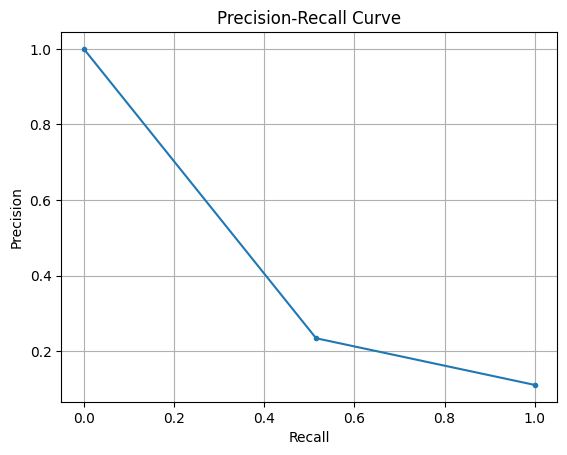

Calculating F1 Score...
F1 Score: 0.3217665615141956
Calculating Accuracy...
Hamming Loss: 0.23968784838350055
Accuracy: 0.7603121516164995


In [43]:

gold_label = full_tsv_run['tsv_label'].to_list()
test_label = full_tsv_run['prob'].to_list()
test_label = [0 if x > 0.4 else 1 for x in test_label]  # Convert probabilities to binary labels

# Plot Precision-Recall Curve
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
precision, recall, thresholds = precision_recall_curve(gold_label, test_label)
#plt.figure(figsize=(10, 6))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid()
plt.show()

from sklearn.metrics import f1_score
print("Calculating F1 Score...")
f1 = f1_score(gold_label, test_label)
print("F1 Score:", f1)
print("Calculating Accuracy...")
from sklearn.metrics import accuracy_score, hamming_loss
hamming = hamming_loss(gold_label, test_label)
print("Hamming Loss:", hamming)
accuracy = accuracy_score(gold_label, test_label)
print("Accuracy:", accuracy)

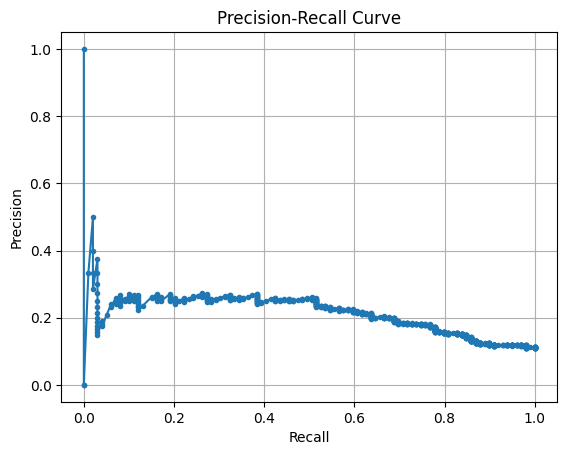

In [44]:

gold_label = full_tsv_run['tsv_label'].to_list()
test_label = full_tsv_run['prob'].to_list()
test_label = [1-x for x in test_label]  # Convert probabilities to binary labels

# Plot Precision-Recall Curve
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
precision, recall, thresholds = precision_recall_curve(gold_label, test_label)
#plt.figure(figsize=(10, 6))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid()
plt.show()

In [ ]:
#load the full tsv runs
tsv_run_base=pd.read_csv(f"{RESULT_DIR}/full_tsv_run_pilot.tsv", sep='\t')
#tsv_run_test=pd.read_csv(f"{RESULT_DIR}/full_tsv_run_pilot_aaaa.tsv", sep='\t')
tsv_run_test=pd.read_csv(f"{RESULT_DIR}/full_tsv_run_pilot_generated.tsv", sep='\t')
#tsv_run_test=pd.read_csv(f"{RESULT_DIR}/full_tsv_run_pilot_lemur+usages.tsv", sep='\t') 

tsv_run_base_suggested = tsv_run_base[tsv_run_base['tsv_step_sense'].str.contains('-')].copy()

tsv_run_base_existing = tsv_run_base[~tsv_run_base['tsv_step_sense'].str.contains('-')].copy()

tsv_run_test_suggested = tsv_run_test[
    tsv_run_test['tsv_step_sense'].str.contains('-')
].copy()

tsv_run_test_existing = tsv_run_test[
    ~tsv_run_test['tsv_step_sense'].str.contains('-', na=False)
].copy()





identifier1 = tsv_run_base['identifier'].to_list()
identifier2 = tsv_run_test['identifier'].to_list()
#check if both lists are equal
if identifier1 == identifier2:
    print("Both identifiers are equal.")
else:
    print("Identifiers are not equal.")

gold_label = tsv_run_base['tsv_label'].to_list()
gold_label_2 = tsv_run_test['tsv_label'].to_list()
gold_label_existing_base = tsv_run_base_existing['tsv_label'].to_list()
gold_label_suggested_base = tsv_run_base_suggested['tsv_label'].to_list()
gold_label_existing_test = tsv_run_test_existing['tsv_label'].to_list()
gold_label_suggested_test = tsv_run_test_suggested['tsv_label'].to_list()


#check if both lists are equal
if gold_label == gold_label_2:
    print("Both gold labels are equal.")
else:
    print("Gold labels are not equal.")

scores_base = tsv_run_base['prob'].to_list()
label_base = [0 if x > 0.4 else 1 for x in scores_base]  # Convert probabilities to binary labels
scores_base = [1-x for x in scores_base]  # Convert probabilities to binary labels

scores_test = tsv_run_test['prob'].to_list()
label_test = [0 if x > 0.4 else 1 for x in scores_test]  # Convert probabilities to binary labels
scores_test = [1-x for x in scores_test]  # Convert probabilities to binary labels

scores_base_existing = tsv_run_base_existing['prob'].to_list()
label_base_existing = [0 if x > 0.4 else 1 for x in scores_base_existing]  # Convert probabilities to binary labels
scores_base_existing = [1-x for x in scores_base_existing]  # Convert probabilities to binary labels

scores_base_suggested= tsv_run_base_suggested['prob'].to_list()
label_base_suggested = [0 if x > 0.4 else 1 for x in scores_base_suggested]  # Convert probabilities to binary labels
scores_base_suggested = [1-x for x in scores_base_suggested]  # Convert probabilities to binary labels

scores_test_suggested = tsv_run_test_suggested['prob'].to_list()
label_test_suggested = [0 if x > 0.4 else 1 for x in scores_test_suggested]  # Convert probabilities to binary labels
scores_test_suggested = [1-x for x in scores_test_suggested]  # Convert probabilities to binary labels

scores_test_existing = tsv_run_test_existing['prob'].to_list()
label_test_existing = [0 if x > 0.4 else 1 for x in scores_test_existing]  # Convert probabilities to binary labels
scores_test_existing = [1-x for x in scores_test_existing]  # Convert probabilities to binary labels

#check if both lists are equal
if scores_base == scores_test:
    print("Both scores are equal.")
else:
    print("Scores are not equal.")

# check if both lists of labels are equal
if label_base == label_test:
    print("Both labels are equal.")
else:
    print("Labels are not equal.")


# Plot Precision-Recall Curve for base run using scores_base
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt
precision_base, recall_base, thresholds_base = precision_recall_curve(gold_label, scores_base, pos_label=1)
plt.plot(recall_base, precision_base, marker='.', label='base run (pilot defs)')
avg_precision_base= sum(precision_base) / len(precision_base)
print("Average Precision for base run:", avg_precision_base)

# Plot Precision-Recall Curve for test run using scores_test
precision_test, recall_test, thresholds_test = precision_recall_curve(gold_label_2, scores_test,  pos_label=1)
plt.plot(recall_test, precision_test, marker='.', label='test run: (input existing def)')
avg_precision_test= sum(precision_test) / len(precision_test)
print("Average Precision for test run:", avg_precision_test)


# Plot Precision-Recall Curve for base using scores_base_existing
precision_test, recall_test, thresholds_test = precision_recall_curve(gold_label_existing_base, scores_base_existing,  pos_label=1)
plt.plot(recall_test, precision_test, marker='.', label='Existing : base run')

# Plot Precision-Recall Curve for test run using scores_test_existing
precision_test, recall_test, thresholds_test = precision_recall_curve(gold_label_existing_test, scores_test_existing,  pos_label=1)
plt.plot(recall_test, precision_test, marker='.', label='Existing : test run')

# Plot Precision-Recall Curve for base using scores_base_suggested
precision_test, recall_test, thresholds_test = precision_recall_curve(gold_label_suggested_base, scores_base_suggested,  pos_label=1)
plt.plot(recall_test, precision_test, marker='.', label='Suggested : base run')

# Plot Precision-Recall Curve for test run using scores_test_suggested
precision_test, recall_test, thresholds_test = precision_recall_curve(gold_label_suggested_test, scores_test_suggested,  pos_label=1)
plt.plot(recall_test, precision_test, marker='.', label='Suggested : test run')
"""
# Generate random scores for comparison
random_scores = np.random.randint(0, 2, size=len(gold_label))
precision_random, recall_random, thresholds_random = precision_recall_curve(gold_label, random_scores, pos_label=1)
plt.plot(recall_random, precision_random, marker='.', label='Random')
"""
# plot pr curve for test run using only suggested definitions from annotator





plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()



#average precision instead of f1 score
# calculate average precision
avg_precision_test= sum(precision_test) / len(precision_test)
print("Average Precision for test run:", avg_precision_test)

avg_precision_base = sum(precision_base) / len(precision_base)
print("Average Precision for base run:", avg_precision_base)



#split plots using ode and felix splitted

#class distrubution for labels
print("Class distribution for labels in base run:")
print(pd.Series(label_base).value_counts())

print("Class distribution for labels in test run:")
print(pd.Series(label_test).value_counts())

print("Class distribution for gold labels:")
print(tsv_run_base['tsv_label'].value_counts())

#reproduce felix plots with 1 sense per lemma run



# EVAL

BASE_DIR: /home/users1/saxjs/BASax/johannes/autodict/pipeline
RESULT_DIR: /home/users1/saxjs/BASax/johannes/eval/results
Identifiers are not equal.
Gold labels are not equal.
Scores are not equal.
Labels are not equal.
Average Precision for base run: 0.21733553067149014
Average Precision for test run: 0.4150690856498111


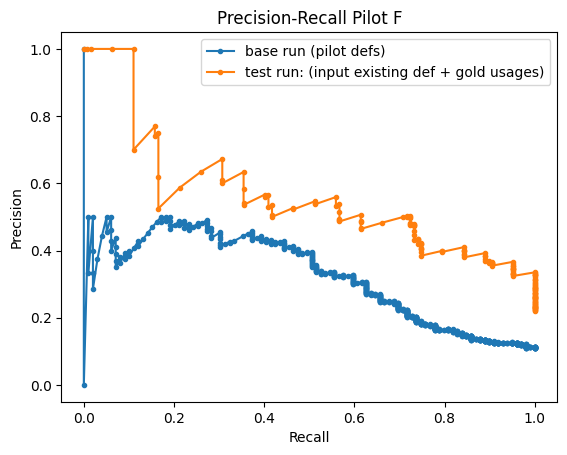

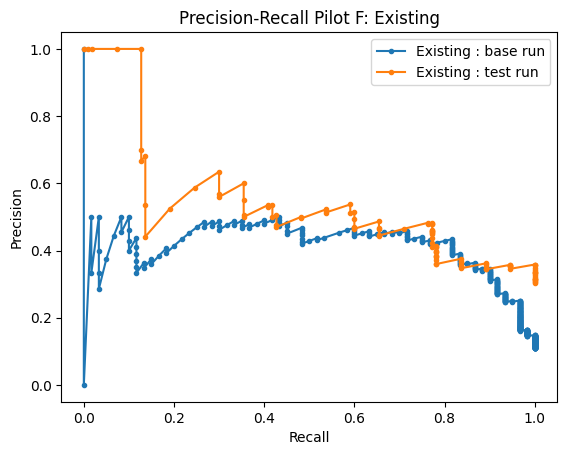

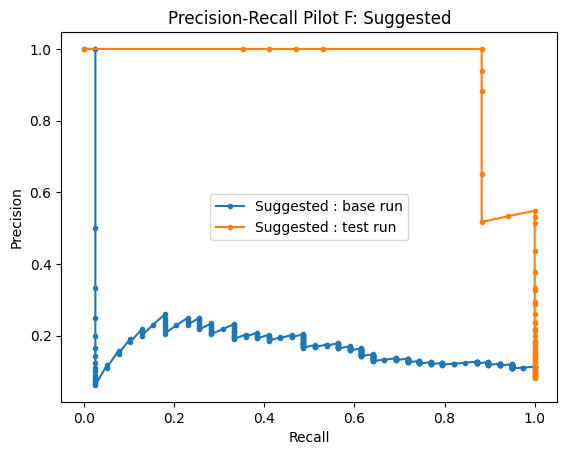

Average Precision for test run: 0.3098044623882725
Average Precision for base run: 0.21733553067149014
Class distribution for labels in base run:
0    1408
1     386
Name: count, dtype: int64
Class distribution for labels in test run:
0    1532
1     764
Name: count, dtype: int64
Class distribution for gold labels:
tsv_label
0.0    1596
1.0     198
Name: count, dtype: int64


In [ ]:
import os
import pandas as pd

# preset paths
BASE_DIR = "/home/users1/saxjs/BASax/johannes/autodict/pipeline"
RESULT_DIR = "/home/users1/saxjs/BASax/johannes/eval/results"

print(f"BASE_DIR: {BASE_DIR}")
print(f"RESULT_DIR: {RESULT_DIR}")



#load the full tsv runs
tsv_run_base=pd.read_csv(f"{RESULT_DIR}/full_tsv_run_pilot.tsv", sep='\t')
#tsv_run_test=pd.read_csv(f"{RESULT_DIR}/full_tsv_run_pilot_aaaa.tsv", sep='\t')
#tsv_run_test=pd.read_csv(f"{RESULT_DIR}/full_tsv_run_pilot_generated.tsv", sep='\t')
tsv_run_test=pd.read_csv(f"{RESULT_DIR}/full_tsv_run_pilot_lemur+usages.tsv", sep='\t') 

tsv_run_base_suggested = tsv_run_base[tsv_run_base['tsv_step_sense'].str.contains('-')].copy()

tsv_run_base_existing = tsv_run_base[~tsv_run_base['tsv_step_sense'].str.contains('-')].copy()

tsv_run_test_suggested = tsv_run_test[
    tsv_run_test['tsv_step_sense'].str.contains('-')
].copy()

tsv_run_test_existing = tsv_run_test[
    ~tsv_run_test['tsv_step_sense'].str.contains('-', na=False)
].copy()





identifier1 = tsv_run_base['identifier'].to_list()
identifier2 = tsv_run_test['identifier'].to_list()
#check if both lists are equal
if identifier1 == identifier2:
    print("Both identifiers are equal.")
else:
    print("Identifiers are not equal.")

gold_label = tsv_run_base['tsv_label'].to_list()
gold_label_2 = tsv_run_test['tsv_label'].to_list()
gold_label_existing_base = tsv_run_base_existing['tsv_label'].to_list()
gold_label_suggested_base = tsv_run_base_suggested['tsv_label'].to_list()
gold_label_existing_test = tsv_run_test_existing['tsv_label'].to_list()
gold_label_suggested_test = tsv_run_test_suggested['tsv_label'].to_list()


#check if both lists are equal
if gold_label == gold_label_2:
    print("Both gold labels are equal.")
else:
    print("Gold labels are not equal.")

scores_base = tsv_run_base['prob'].to_list()
label_base = [0 if x > 0.4 else 1 for x in scores_base]  # Convert probabilities to binary labels
scores_base = [1-x for x in scores_base]  # Convert probabilities to binary labels

scores_test = tsv_run_test['prob'].to_list()
label_test = [0 if x > 0.4 else 1 for x in scores_test]  # Convert probabilities to binary labels
scores_test = [1-x for x in scores_test]  # Convert probabilities to binary labels

scores_base_existing = tsv_run_base_existing['prob'].to_list()
label_base_existing = [0 if x > 0.4 else 1 for x in scores_base_existing]  # Convert probabilities to binary labels
scores_base_existing = [1-x for x in scores_base_existing]  # Convert probabilities to binary labels

scores_base_suggested= tsv_run_base_suggested['prob'].to_list()
label_base_suggested = [0 if x > 0.4 else 1 for x in scores_base_suggested]  # Convert probabilities to binary labels
scores_base_suggested = [1-x for x in scores_base_suggested]  # Convert probabilities to binary labels

scores_test_suggested = tsv_run_test_suggested['prob'].to_list()
label_test_suggested = [0 if x > 0.4 else 1 for x in scores_test_suggested]  # Convert probabilities to binary labels
scores_test_suggested = [1-x for x in scores_test_suggested]  # Convert probabilities to binary labels

scores_test_existing = tsv_run_test_existing['prob'].to_list()
label_test_existing = [0 if x > 0.4 else 1 for x in scores_test_existing]  # Convert probabilities to binary labels
scores_test_existing = [1-x for x in scores_test_existing]  # Convert probabilities to binary labels



# Plot Precision-Recall Curve for base run using scores_base
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

precision_base, recall_base, thresholds_base = precision_recall_curve(gold_label, scores_base, pos_label=1)
plt.plot(recall_base, precision_base, marker='.', label='base run (pilot defs)')
avg_precision_base= sum(precision_base) / len(precision_base)
print("Average Precision for base run:", avg_precision_base)

# Plot Precision-Recall Curve for test run using scores_test
precision_test, recall_test, thresholds_test = precision_recall_curve(gold_label_2, scores_test,  pos_label=1)
plt.plot(recall_test, precision_test, marker='.', label='test run: (input existing def + gold usages)')
avg_precision_test= sum(precision_test) / len(precision_test)
print("Average Precision for test run:", avg_precision_test)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Pilot F')
plt.legend()
plt.show()


# Plot Precision-Recall Curve for base using scores_base_existing
precision_test, recall_test, thresholds_test = precision_recall_curve(gold_label_existing_base, scores_base_existing,  pos_label=1)
plt.plot(recall_test, precision_test, marker='.', label='Existing : base run')

# Plot Precision-Recall Curve for test run using scores_test_existing
precision_test, recall_test, thresholds_test = precision_recall_curve(gold_label_existing_test, scores_test_existing,  pos_label=1)
plt.plot(recall_test, precision_test, marker='.', label='Existing : test run')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Pilot F: Existing')
plt.legend()
plt.show()


# Plot Precision-Recall Curve for base using scores_base_suggested
precision_test, recall_test, thresholds_test = precision_recall_curve(gold_label_suggested_base, scores_base_suggested,  pos_label=1)
plt.plot(recall_test, precision_test, marker='.', label='Suggested : base run')

# Plot Precision-Recall Curve for test run using scores_test_suggested
precision_test, recall_test, thresholds_test = precision_recall_curve(gold_label_suggested_test, scores_test_suggested,  pos_label=1)
plt.plot(recall_test, precision_test, marker='.', label='Suggested : test run')
"""
# Generate random scores for comparison
random_scores = np.random.randint(0, 2, size=len(gold_label))
precision_random, recall_random, thresholds_random = precision_recall_curve(gold_label, random_scores, pos_label=1)
plt.plot(recall_random, precision_random, marker='.', label='Random')
"""
# plot pr curve for test run using only suggested definitions from annotator





plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Pilot F: Suggested')
plt.legend()
plt.show()



#average precision instead of f1 score
# calculate average precision
avg_precision_test= sum(precision_test) / len(precision_test)
print("Average Precision for test run:", avg_precision_test)

avg_precision_base = sum(precision_base) / len(precision_base)
print("Average Precision for base run:", avg_precision_base)



#split plots using ode and felix splitted

#class distrubution for labels
print("Class distribution for labels in base run:")
print(pd.Series(label_base).value_counts())

print("Class distribution for labels in test run:")
print(pd.Series(label_test).value_counts())

print("Class distribution for gold labels:")
print(tsv_run_base['tsv_label'].value_counts())

#reproduce felix plots with 1 sense per lemma run



# TEST

In [2]:
import os
import pandas as pd
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score

# preset paths
#baseline_path="/home/users1/saxjs/BASax/ba_pipeline/OUTPilot_baseline/full_tsv_run.tsv"
#test_path="/home/users1/saxjs/BASax/ba_pipeline/OUTPilot_best_sum_usages/full_tsv_run.tsv"

baseline_path="/home/users1/saxjs/BASax/johannes/ba_pipeline/OUTFEWS_train_ext_run1/full_tsv_run.tsv"
test_path="/home/users1/saxjs/BASax/johannes/ba_pipeline/OUTFEWS_train_ext_run1/full_tsv_run.tsv"


#load the full tsv runs
tsv_run_base=pd.read_csv(baseline_path, sep='\t')
tsv_run_test=pd.read_csv(test_path, sep='\t')

score_gold= tsv_run_base['tsv_label'].to_list()
score_base= tsv_run_base['prob'].to_list()
score_base=[1-x for x in score_base]


print("Calculating AVG Precision")
avg_score=average_precision_score(score_gold, score_base)
print(f"Average Precision for baseline run: {avg_score:.2f}")

avg_test=average_precision_score(score_gold, score_base)
"""
for group in tsv_run_base.groupby("tsv_step_sense"):
    # Compare each group in the baseline with the test
    baseline_group = group[0]
    print(f"sense: {group[0]}")
    #print(f"Baseline group: ")
    #display(group)
    print(f"Number of rows in group: {len(group[1])}")

    base_rows=tsv_run_base[tsv_run_base['tsv_step_sense'] == baseline_group]
    base_gold= base_rows["tsv_label"].to_list()
    base_scores= base_rows["prob"].to_list()
    base_scores=[1-x for x in base_scores]

    precision_base, recall_base, thresholds_base = precision_recall_curve(base_gold, base_scores, pos_label=1)

    # Calculate average precision
    avg_precision_base = np.mean(precision_base)
    print(f"Average precision for group {baseline_group}: {avg_precision_base}")

    #now for test
    test_rows = tsv_run_test[tsv_run_test['tsv_step_sense'] == baseline_group]
    test_gold = test_rows["tsv_label"].to_list()
    test_scores = test_rows["prob"].to_list()
    test_scores = [1-x for x in test_scores]

    precision_test, recall_test, thresholds_test = precision_recall_curve(test_gold, test_scores, pos_label=1)

    # Calculate average precision
    avg_precision_test = np.mean(precision_test)
    print(f"Average precision for group {baseline_group}: {avg_precision_test}")

    #create pr plot comparing base and test
    plt.figure(figsize=(3, 2))
    plt.plot(recall_base, precision_base, label=f'Baseline (AP: {avg_precision_base:.2f})')
    plt.plot(recall_test, precision_test, label=f'Test (AP: {avg_precision_test:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve for Sense {baseline_group}')
    plt.legend()
    plt.grid()
    plt.savefig(f"/home/users1/saxjs/BASax/ba_pipeline/plots/single/pr_curve_{baseline_group}.png", dpi=300, bbox_inches='tight')
    plt.show()
"""



Calculating AVG Precision
Average Precision for baseline run: 0.25


'\nfor group in tsv_run_base.groupby("tsv_step_sense"):\n    # Compare each group in the baseline with the test\n    baseline_group = group[0]\n    print(f"sense: {group[0]}")\n    #print(f"Baseline group: ")\n    #display(group)\n    print(f"Number of rows in group: {len(group[1])}")\n\n    base_rows=tsv_run_base[tsv_run_base[\'tsv_step_sense\'] == baseline_group]\n    base_gold= base_rows["tsv_label"].to_list()\n    base_scores= base_rows["prob"].to_list()\n    base_scores=[1-x for x in base_scores]\n\n    precision_base, recall_base, thresholds_base = precision_recall_curve(base_gold, base_scores, pos_label=1)\n\n    # Calculate average precision\n    avg_precision_base = np.mean(precision_base)\n    print(f"Average precision for group {baseline_group}: {avg_precision_base}")\n\n    #now for test\n    test_rows = tsv_run_test[tsv_run_test[\'tsv_step_sense\'] == baseline_group]\n    test_gold = test_rows["tsv_label"].to_list()\n    test_scores = test_rows["prob"].to_list()\n    test_

In [ ]:
import math
import matplotlib.pyplot as plt

# Get unique groups
unique_groups = sorted(tsv_run_base["tsv_step_sense"].unique())
n_groups = len(unique_groups)

# Define subplot grid (e.g. 2 columns, as many rows as needed)
n_cols = 4
n_rows = math.ceil(n_groups / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()  # flatten for easy indexing

for idx, baseline_group in enumerate(unique_groups):
    ax = axes[idx]

    # baseline
    base_rows = tsv_run_base[tsv_run_base['tsv_step_sense'] == baseline_group]
    base_gold = base_rows["tsv_label"].astype(int).to_list()
    base_scores = [1-x for x in base_rows["prob"].to_list()]
    precision_base, recall_base, _ = precision_recall_curve(base_gold, base_scores, pos_label=1)
    avg_precision_base = np.mean(precision_base)

    # test
    test_rows = tsv_run_test[tsv_run_test['tsv_step_sense'] == baseline_group]
    test_gold = test_rows["tsv_label"].astype(int).to_list()
    test_scores = [1-x for x in test_rows["prob"].to_list()]
    precision_test, recall_test, _ = precision_recall_curve(test_gold, test_scores, pos_label=1)
    avg_precision_test = np.mean(precision_test)

    # plot into the correct subplot
    ax.plot(recall_base, precision_base, label=f'Baseline (AP: {avg_precision_base:.4f})')
    ax.plot(recall_test, precision_test, label=f'Test (AP: {avg_precision_test:.4f})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'Sense {baseline_group}; tsv-examples: {len(base_rows)}')
    ax.legend()
    ax.grid()

# Hide unused axes (if any)
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7f90c2dab490> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
import math
import matplotlib.pyplot as plt
#show 1 and 0 tsv label distribution for each lemma
group_by_lemma= tsv_run_base.groupby('lemma')
for lemma, group in group_by_lemma:
    label_distribution = group['tsv_label'].astype(int).value_counts()
    print(f"Label distribution for lemma '{lemma}':")
    print(label_distribution)
    print()

# create a nice table for grouped by sense_id
group_by_sense_id = tsv_run_base.groupby('tsv_step_sense')
distribution=[]
for sense_id, group in group_by_sense_id:
    label_distribution = group['tsv_label'].astype(int).value_counts()
    print(f"Label distribution for sense_id '{sense_id}':")
    print(label_distribution)
    zero_label=label_distribution.get(0, 0)
    one_label=label_distribution.get(1, 0)
    distribution.append((sense_id, zero_label, one_label))
    #print(f"Zero label: {zero_label}, One label: {one_label}")

distribution_df = pd.DataFrame(distribution, columns=['sense_id', 'tsv_0', 'tsv_1'])
display(distribution_df)

Label distribution for lemma 'A cup':
tsv_label
1    2
0    2
Name: count, dtype: int64

Label distribution for lemma 'Abraham':
tsv_label
0    4
1    1
Name: count, dtype: int64

Label distribution for lemma 'Afro-Indian':
tsv_label
0    8
1    2
Name: count, dtype: int64

Label distribution for lemma 'Ajax':
tsv_label
0    35
1     5
Name: count, dtype: int64

Label distribution for lemma 'Alemanni':
tsv_label
0    6
1    2
Name: count, dtype: int64

Label distribution for lemma 'Ananias':
tsv_label
1    2
0    2
Name: count, dtype: int64

Label distribution for lemma 'Armstrongian':
tsv_label
1    2
0    2
Name: count, dtype: int64

Label distribution for lemma 'Aryan':
tsv_label
0    77
1     7
Name: count, dtype: int64

Label distribution for lemma 'Atlantean':
tsv_label
0    45
1     5
Name: count, dtype: int64

Label distribution for lemma 'Baltic':
tsv_label
0    40
1     5
Name: count, dtype: int64

Label distribution for lemma 'Beatledom':
tsv_label
1    1
0    1
Name: count,

,sense_id,tsv_0,tsv_1
0,a_cup.noun.0,2,0
1,a_cup.noun.1,0,2
2,abandoned.adjective.0,6,1
3,abandoned.adjective.1,6,1
4,abandoned.adjective.2,6,1
...,...,...,...
17816,zero.verb.2,15,1
17817,zero.verb.3,16,0
17818,zero.verb.4,16,0
17819,zoning.noun.0,0,1


['again.adverb.0', 'ambitious.adjective.2', 'apt.adjective.2', 'backhanded.adjective.2', 'beat.verb.2', 'blush.verb.0', 'bomb.noun.6', 'borrow.verb.5', 'boy.noun.9', 'bright.adjective.0', 'chill.noun.7', 'clear.adverb.3', 'clutch.noun.8', 'cold.adjective.7', 'composition.noun.4', 'connected.adjective.1', 'credit.noun.1', 'cross.adjective.2', 'damp.noun.0', 'damp.noun.2', 'dark.adjective.5', 'dark.noun.1', 'dead.adjective.16', 'dead.adjective.17', 'distance.noun.7', 'due.adjective.0', 'egg-crated.adjective.0', 'embrace.verb.2', 'exact.adjective.0', 'exact.adjective.1', 'fair.adjective.0', 'fast.adjective.4', 'foul.adjective.0', 'free.adjective.0', 'full.noun.0', 'gee.noun.4', 'greenie.noun.4', 'gross.adjective.0', 'happy.adjective.0', 'happy.adjective.3', 'head.noun.8', 'heat.noun.6', 'high.adjective.17', 'hit.verb.1', 'jigger.noun.30', 'light.noun.0', 'long.adverb.2', 'low.adjective.4', 'man.noun.2', 'material.adjective.2', 'name.noun.0', 'nappy.adjective.4', 'only.adverb.1', 'over.adv

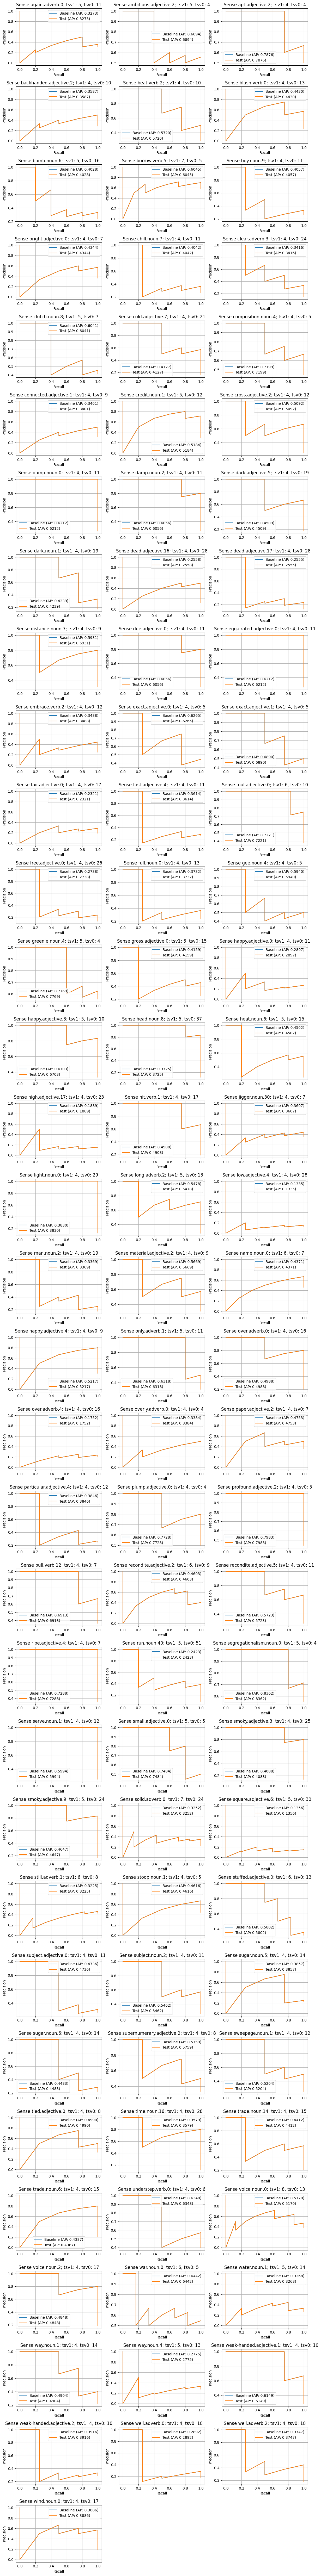

In [8]:
import math
import matplotlib.pyplot as plt
# remove from unique_groups all entries where distribution_def['tsv_1'] is below 8
unique_groups = sorted(tsv_run_base["tsv_step_sense"].unique())
unique_groups = [group for group in unique_groups if distribution_df[distribution_df['sense_id'] == group]['tsv_1'].values[0] >= 4]
unique_groups = [group for group in unique_groups if distribution_df[distribution_df['sense_id'] == group]['tsv_0'].values[0] >= 4]
print(unique_groups)

n_groups = len(unique_groups)

# Define subplot grid (e.g. 2 columns, as many rows as needed)
n_cols = 3
n_rows = math.ceil(n_groups / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()  # flatten for easy indexing

for idx, baseline_group in enumerate(unique_groups):
    ax = axes[idx]

    # baseline
    base_rows = tsv_run_base[tsv_run_base['tsv_step_sense'] == baseline_group]
    base_gold = base_rows["tsv_label"].astype(int).to_list()
    # Count number of 1s in base_gold for this group
    gold_t1 = sum(base_gold)
    # count number of 0s in base_gold for this group
    gold_t0 = len(base_gold) - gold_t1

    base_scores = [1-x for x in base_rows["prob"].to_list()]
    precision_base, recall_base, _ = precision_recall_curve(base_gold, base_scores, pos_label=1)
    avg_precision_base = np.mean(precision_base)

    # test
    test_rows = tsv_run_test[tsv_run_test['tsv_step_sense'] == baseline_group]
    test_gold = test_rows["tsv_label"].astype(int).to_list()
    test_scores = [1-x for x in test_rows["prob"].to_list()]
    precision_test, recall_test, _ = precision_recall_curve(test_gold, test_scores, pos_label=1)
    avg_precision_test = np.mean(precision_test)

    # plot into the correct subplot
    ax.plot(recall_base, precision_base, label=f'Baseline (AP: {avg_precision_base:.4f})')
    ax.plot(recall_test, precision_test, label=f'Test (AP: {avg_precision_test:.4f})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'Sense {baseline_group}; tsv1: {gold_t1}, tsv0: {gold_t0}')
    ax.legend()
    ax.grid()

# Hide unused axes (if any)
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
#plt.savefig("/home/users1/saxjs/BASax/ba_pipeline/plots/precision_recall_pilot_+8.png")
plt.show()



In [6]:
from nltk.corpus import wordnet as wn

# Make sure WordNet is downloaded
import nltk
nltk.download('wordnet')
#nltk.download('omw-1.4')

# Example word
word = "gather"

# Get synsets (senses) of the word
synsets = wn.synsets(word)

print(f"Definitions of '{word}':\n")
for i, syn in enumerate(synsets, 1):
    print(f"{i}. {syn.definition()}")


Definitions of 'gather':

1. sewing consisting of small folds or puckers made by pulling tight a thread in a line of stitching
2. the act of gathering something
3. assemble or get together
4. collect in one place
5. collect or gather
6. conclude from evidence
7. draw together into folds or puckers
8. get people together
9. draw and bring closer
10. look for (food) in nature
11. increase or develop


[nltk_data] Downloading package wordnet to
[nltk_data]     /home/users1/saxjs/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
